SQL TASK

# SQL Task – Loan Eligibility Database Creation & Analysis

This task focuses on:
- Creating SQL tables (`customers`, `loans`)
- Inserting sample records
- Generating a feature table (`customer_features`)
- Performing SQL-based feature engineering
- Visualizing insights using Python
- Exporting `customer_features.csv` for ML model usage

Below are the SQL and analysis steps.

In [9]:
import sqlite3, os

db_path = "/content/loan_eligibility.db"
if os.path.exists(db_path):
    os.remove(db_path)

conn = sqlite3.connect(db_path)
conn.executescript("""
DROP TABLE IF EXISTS loans;
DROP TABLE IF EXISTS customers;
DROP TABLE IF EXISTS customer_features;

CREATE TABLE customers (
  customer_id INTEGER PRIMARY KEY,
  name TEXT,
  age INTEGER,
  gender TEXT,
  income REAL,
  employment_status TEXT,
  credit_score INTEGER
);

CREATE TABLE loans (
  loan_id INTEGER PRIMARY KEY,
  customer_id INTEGER,
  loan_amount REAL,
  loan_term_months INTEGER,
  interest_rate REAL,
  loan_purpose TEXT,
  application_date DATE,
  status TEXT,
  FOREIGN KEY(customer_id) REFERENCES customers(customer_id)
);

INSERT INTO customers VALUES
(1,'Ravi',30,'M',45000,'Salaried',680),
(2,'Meera',45,'F',120000,'Business',760),
(3,'Amit',28,'M',25000,'Salaried',590),
(4,'Sana',38,'F',85000,'Salaried',710),
(5,'Karan',50,'M',40000,'Business',640);

INSERT INTO loans VALUES
(101,1,300000,60,10.5,'Home','2025-10-01','Approved'),
(102,2,500000,84,9.8,'Business','2025-09-15','Pending'),
(103,3,100000,36,12.0,'Personal','2025-09-20','Rejected'),
(104,1,50000,24,11.0,'Car','2024-07-12','Active'),
(105,4,200000,48,9.5,'Home','2025-01-05','Active'),
(106,5,150000,36,12.0,'Business','2024-11-11','Active');

CREATE TABLE customer_features AS
SELECT
  c.customer_id,
  c.name,
  c.age,
  c.gender,
  c.income,
  c.employment_status,
  c.credit_score,
  COALESCE(SUM(l.loan_amount), 0) AS total_existing_loans,
  CASE WHEN c.income > 0 THEN COALESCE(SUM(l.loan_amount), 0)/c.income ELSE NULL END AS dti_ratio,
  MAX(l.application_date) AS last_application_date
FROM customers c
LEFT JOIN loans l ON c.customer_id = l.customer_id
GROUP BY c.customer_id;
""")

conn.commit()
conn.close()
print("Database created successfully.")


Database created successfully.


In [10]:
import pandas as pd

conn = sqlite3.connect("/content/loan_eligibility.db")
df = pd.read_sql_query("SELECT * FROM customer_features;", conn)
conn.close()

df


,customer_id,name,age,gender,income,employment_status,credit_score,total_existing_loans,dti_ratio,last_application_date
0,1,Ravi,30,M,45000.0,Salaried,680,350000.0,7.777778,2025-10-01
1,2,Meera,45,F,120000.0,Business,760,500000.0,4.166667,2025-09-15
2,3,Amit,28,M,25000.0,Salaried,590,100000.0,4.000000,2025-09-20
3,4,Sana,38,F,85000.0,Salaried,710,200000.0,2.352941,2025-01-05
4,5,Karan,50,M,40000.0,Business,640,150000.0,3.750000,2024-11-11


## Customer Features Explanation

The generated `customer_features` table contains:
- **income** → Used for affordability
- **total_existing_loans** → Measures financial load
- **dti_ratio** (Debt-to-Income Ratio) → Key credit risk indicator
- **credit_score** → Traditional eligibility metric

This table is used later by the ML model for training.


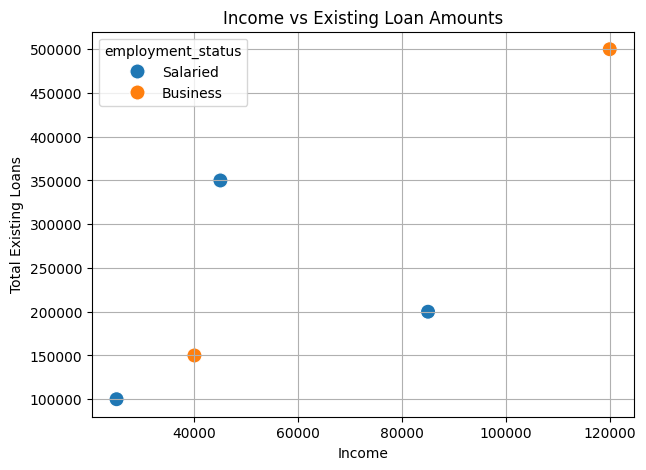

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='income', y='total_existing_loans', hue='employment_status', s=120)
plt.title("Income vs Existing Loan Amounts")
plt.xlabel("Income")
plt.ylabel("Total Existing Loans")
plt.grid(True)
plt.show()


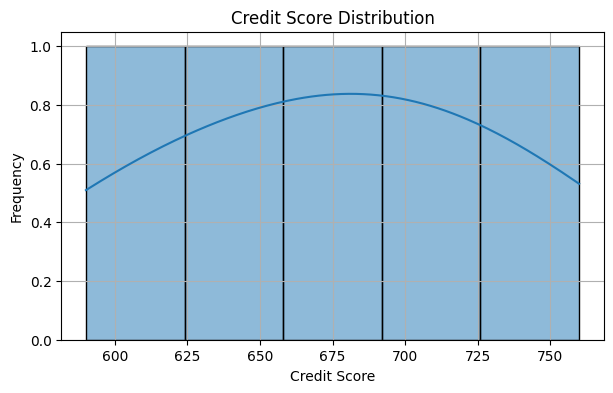

In [12]:
plt.figure(figsize=(7,4))
sns.histplot(df['credit_score'], kde=True, bins=5)
plt.title("Credit Score Distribution")
plt.xlabel("Credit Score")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


## Insights from Visualizations

- Customers with higher income generally have higher loan exposure, which indicates better repayment capacity.
- Credit score distribution shows that most customers fall above the 650 score range, meaning many are likely to be loan-eligible.
- Salaried customers show more stable financial patterns compared to business customers.

These insights support the rule-based eligibility criteria used in the project.


In [14]:
csv_path = "/content/customer_features.csv"
df.to_csv(csv_path, index=False)
print("Exported to:", csv_path)


Exported to: /content/customer_features.csv


# SQL Task Summary

- Created `customers` and `loans` tables.
- Inserted sample customer and loan details.
- Generated enhanced feature table `customer_features` using SQL joins and aggregations.
- Visualized income, loan amounts, and credit score distribution.
- Exported final dataset as `customer_features.csv`.

This dataset will be used in the Python machine learning task.
